#  Customer Churn Prediction
### Telco Customer Churn Dataset — Full ML Pipeline

**Steps covered:**
1. Data Cleaning & Preprocessing
2. Feature Engineering (tenure, usage patterns)
3. Model Training (Logistic Regression, Random Forest, XGBoost)
4. Evaluation (ROC-AUC, Precision, Recall)
5. Model Explainability (SHAP)
6. Business Impact Analysis

**Dataset:** [Telco Customer Churn on Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)


## Install & Import Libraries

In [31]:
# Install required libraries (run once)
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap imbalanced-learn -q

Note: you may need to restart the kernel to use updated packages.


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('All libraries imported successfully!')

All libraries imported successfully!



## Step 1: Load & Explore the Data

In [34]:
import subprocess
import sys

subprocess.run([sys.executable, "-m", "pip", "install", "pyxlsb"])
subprocess.run([sys.executable, "-m", "pip", "install", "xlwt"])
subprocess.run([sys.executable, "-m", "pip", "install", "openpyxl"])


CompletedProcess(args=['/opt/homebrew/opt/python@3.11/bin/python3.11', '-m', 'pip', 'install', 'openpyxl'], returncode=0)

In [35]:
#load dataset
#Download from: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

df = pd.read_csv('dataset/WA_Fn-UseC_-Telco-Customer-Churn.xls')
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [36]:
# Basic info
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Target Distribution ===')
print(df['Churn'].value_counts())
print(f'\nChurn Rate: {df["Churn"].value_counts(normalize=True)["Yes"]*100:.1f}%')

=== Data Types ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pap

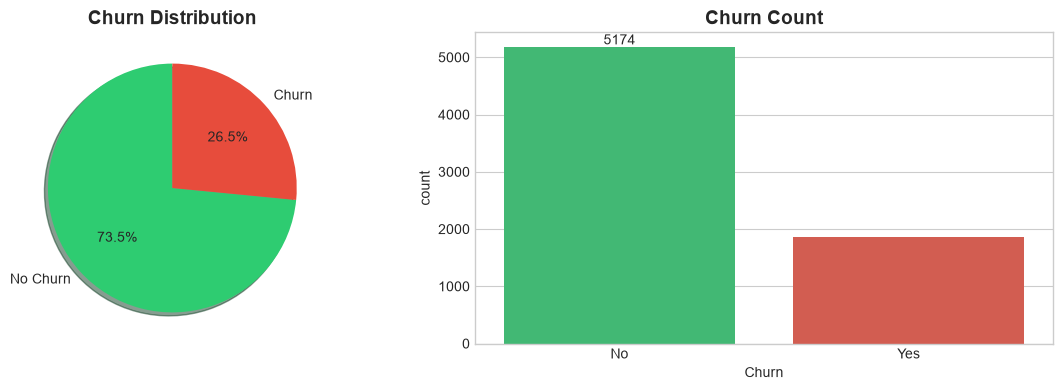

 Class imbalance detected: ~26% churn rate → will apply SMOTE later


In [37]:
# Visualize churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, shadow=True)
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')

# Bar chart
sns.countplot(x='Churn', data=df, ax=axes[1],
              palette={'Yes': '#e74c3c', 'No': '#2ecc71'})
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[1].bar_label(axes[1].containers[0])

plt.tight_layout()
plt.savefig('01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Class imbalance detected: ~26% churn rate → will apply SMOTE later')

In [38]:
print('Statistical Summary')
df.describe()


Statistical Summary


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [39]:
print(f'Duplicate rows: {df.duplicated().sum()}')


Duplicate rows: 0


In [40]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'TotalCharges nulls after conversion: {df["TotalCharges"].isnull().sum()}')


TotalCharges nulls after conversion: 11


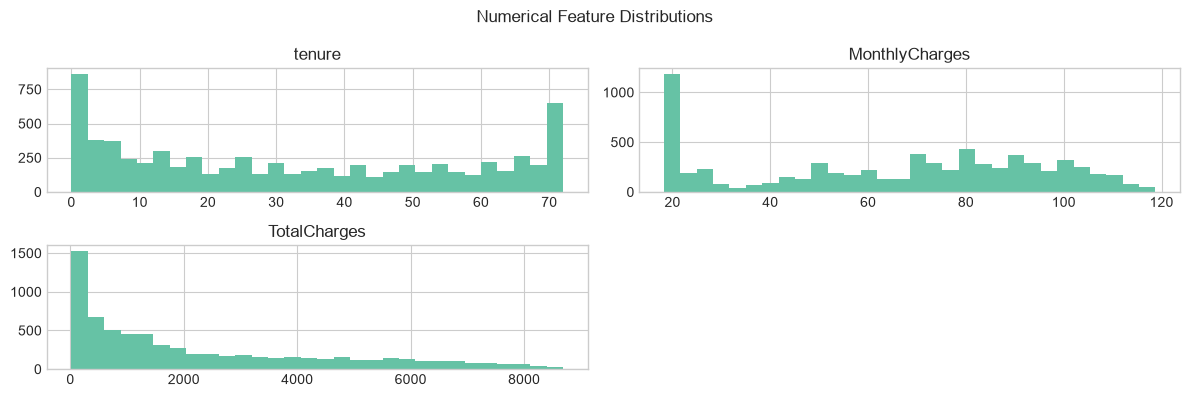

In [41]:
import matplotlib.pyplot as plt

df[['tenure', 'MonthlyCharges', 'TotalCharges']].hist(bins=30, figsize=(12, 4))
plt.suptitle('Numerical Feature Distributions')
plt.tight_layout()
plt.show()


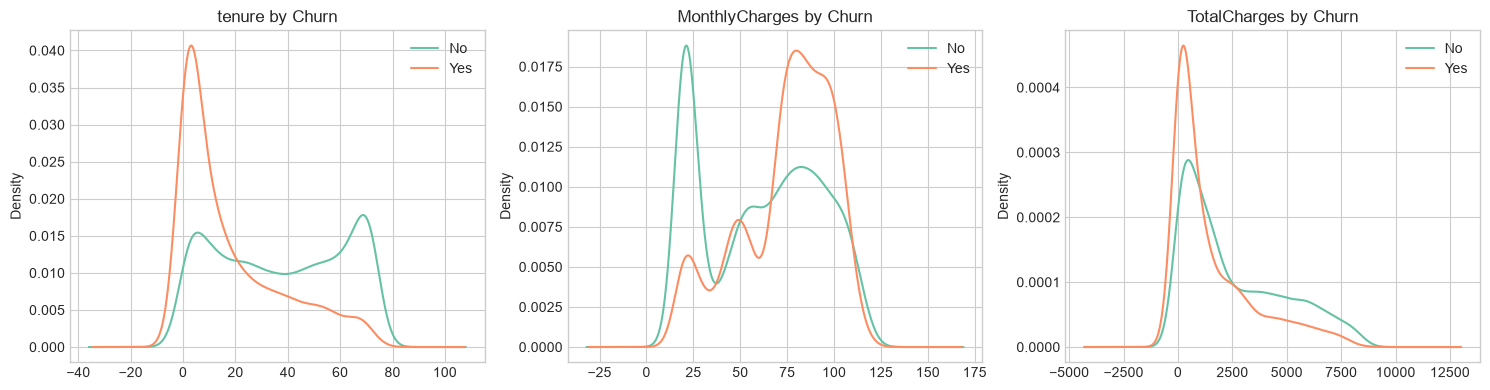

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    df.groupby('Churn')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()


---
## Step 2: Data Cleaning & Preprocessing

In [43]:
#  Fix TotalCharges (stored as string with blank spaces) 
print('TotalCharges dtype before:', df['TotalCharges'].dtype)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'Rows with NaN TotalCharges: {df["TotalCharges"].isna().sum()}')

# Drop rows with NaN (11 new customers with tenure=0)
df.dropna(inplace=True)
print(f'Shape after cleaning: {df.shape}')

# Drop customerID 
df.drop('customerID', axis=1, inplace=True)

#  Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('\nData cleaned!')
df.head(3)

TotalCharges dtype before: float64
Rows with NaN TotalCharges: 11
Shape after cleaning: (7032, 21)

Data cleaned!


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


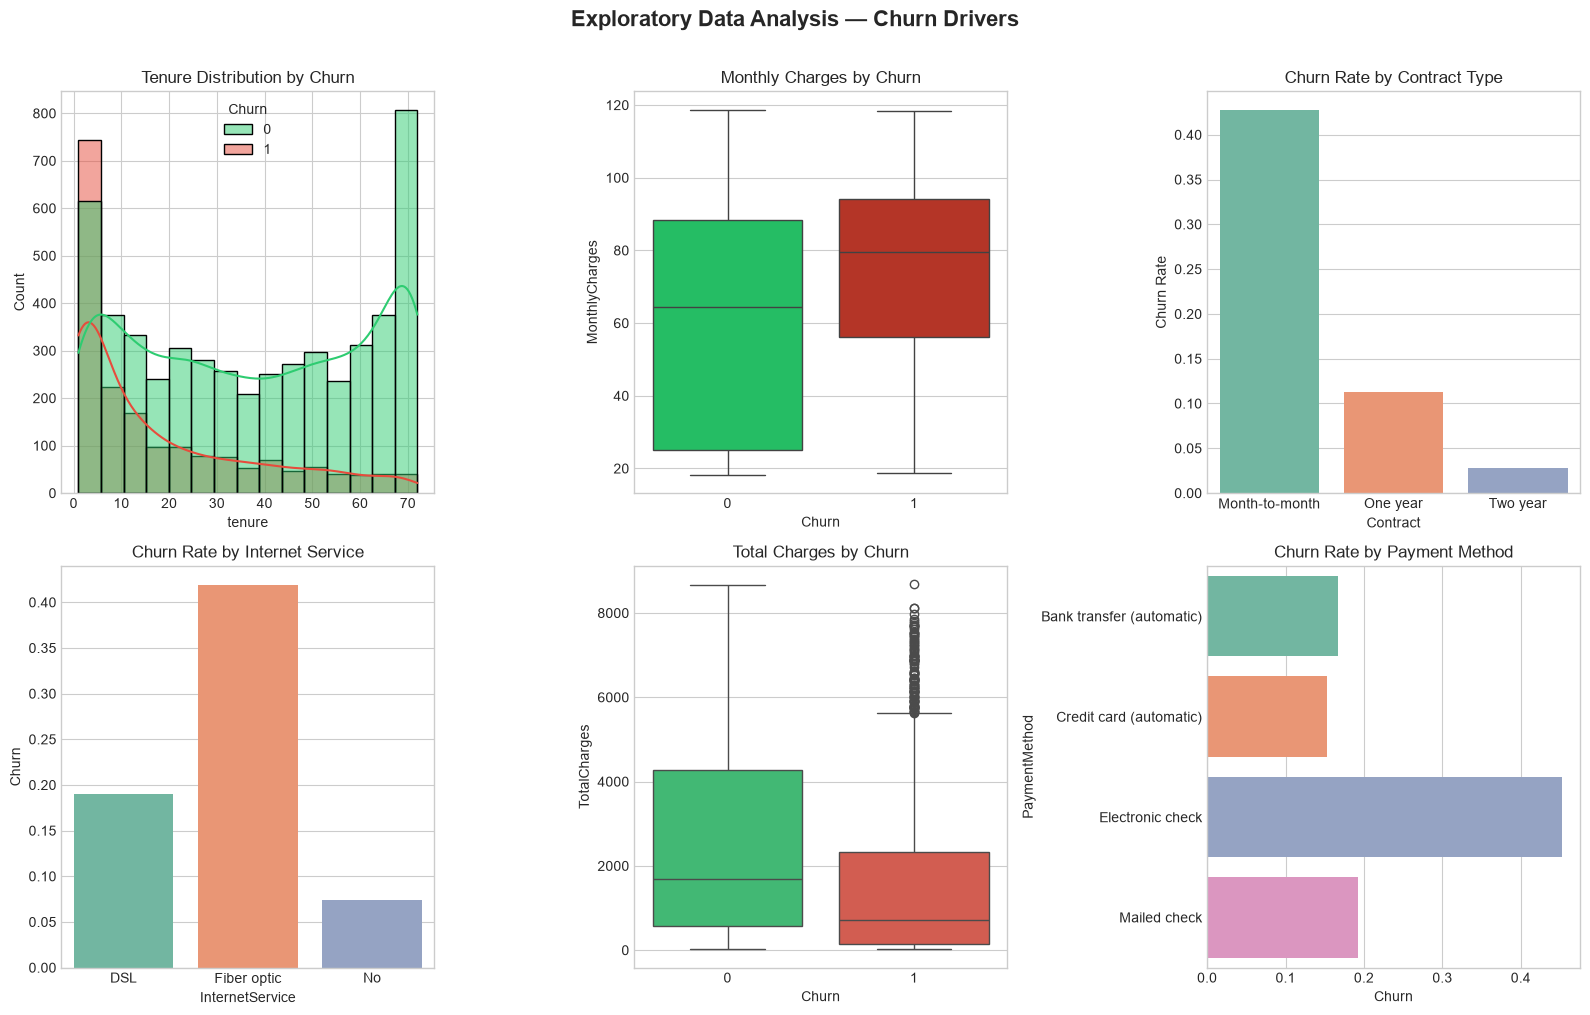

In [44]:
# Exploratory Analysis: Key relationships
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Tenure vs Churn
sns.histplot(data=df, x='tenure', hue='Churn', kde=True,
             ax=axes[0,0], palette={0:'#2ecc71', 1:'#e74c3c'})
axes[0,0].set_title('Tenure Distribution by Churn')

# 2. Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df,
            ax=axes[0,1], hue='Churn', palette={0:"#0cd660", 1:"#cc220f"}, legend=False)
axes[0,1].set_title('Monthly Charges by Churn')

# 3. Contract Type vs Churn
contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()
sns.barplot(x='Contract', y='Churn', data=contract_churn,
            ax=axes[0,2], palette='Set2')
axes[0,2].set_title('Churn Rate by Contract Type')
axes[0,2].set_ylabel('Churn Rate')

# 4. Internet Service vs Churn
net_churn = df.groupby('InternetService')['Churn'].mean().reset_index()
sns.barplot(x='InternetService', y='Churn', data=net_churn,
            ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Churn Rate by Internet Service')

# 5. Total Charges vs Churn
sns.boxplot(x='Churn', y='TotalCharges', data=df,
            ax=axes[1,1], hue='Churn', palette={0:'#2ecc71', 1:'#e74c3c'}, legend=False)
axes[1,1].set_title('Total Charges by Churn')

# 6. Payment Method vs Churn
pay_churn = df.groupby('PaymentMethod')['Churn'].mean().reset_index()
sns.barplot(x='Churn', y='PaymentMethod', data=pay_churn,
            ax=axes[1,2], palette='Set2', orient='h')
axes[1,2].set_title('Churn Rate by Payment Method')

plt.suptitle('Exploratory Data Analysis — Churn Drivers',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

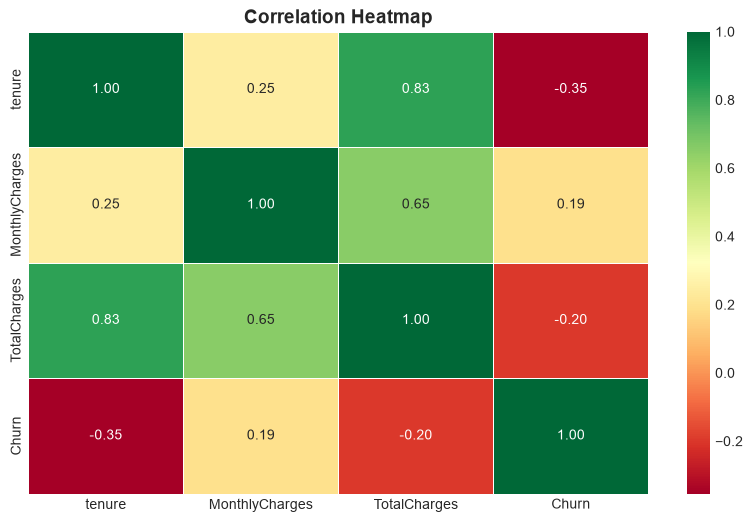

In [45]:
# correlation heatmap
plt.figure(figsize=(10, 6))
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.savefig('03_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


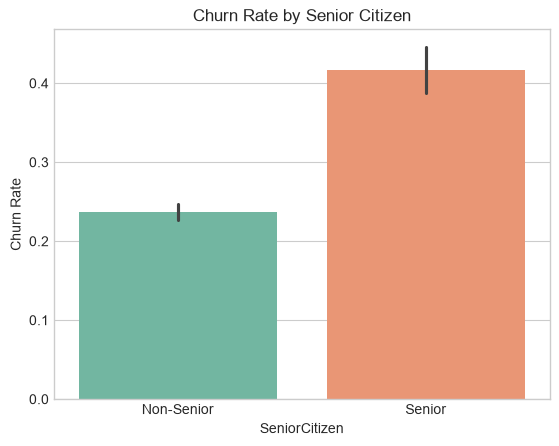

In [46]:
# senior citizen churn rate

sns.barplot(x='SeniorCitizen', y='Churn', data=df, palette='Set2')
plt.title('Churn Rate by Senior Citizen')
plt.xticks([0, 1], ['Non-Senior', 'Senior'])
plt.ylabel('Churn Rate')
plt.show()


## Key Insights from EDA
- Customers with month-to-month contracts churn the most (~42%)
- Fiber optic internet users have higher churn (~41%)
- Electronic check payment users churn more
- Short tenure customers are more likely to churn
- Higher monthly charges correlate with churn



## Step 3: Feature Engineering

In [47]:
# 1. Tenure Group (usage lifecycle stage) 
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 60, 72],
    labels=['New (0-1yr)', 'Early (1-2yr)', 'Mid (2-4yr)',
            'Loyal (4-5yr)', 'Champion (5-6yr)']
)

# 2. Monthly-to-Total Charge Ratio (usage intensity)
# High ratio = customer hasn't been around long → higher churn risk
df['charge_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

#3. Number of Add-on Services subscribed
service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
df['num_services'] = df[service_cols].apply(
    lambda x: (x == 'Yes').sum(), axis=1
)

# 4. Has Phone AND Internet (bundle customer)
df['is_bundle'] = (
    (df['PhoneService'] == 'Yes') &
    (df['InternetService'] != 'No')
).astype(int)

# 5. Senior on month-to-month contract (high risk combo)
df['senior_monthly'] = (
    (df['SeniorCitizen'] == 1) &
    (df['Contract'] == 'Month-to-month')
).astype(int)

print('Feature engineering complete!')
print(f'New features added: tenure_group, charge_ratio, num_services, is_bundle, senior_monthly')
print(f'\nNew shape: {df.shape}')
df[['tenure', 'tenure_group', 'charge_ratio', 'num_services',
    'is_bundle', 'senior_monthly', 'Churn']].head(5)

Feature engineering complete!
New features added: tenure_group, charge_ratio, num_services, is_bundle, senior_monthly

New shape: (7032, 25)


,tenure,tenure_group,charge_ratio,num_services,is_bundle,senior_monthly,Churn
0,1,New (0-1yr),0.967585,1,0,0,0
1,34,Mid (2-4yr),0.030124,2,1,0,0
2,2,New (0-1yr),0.493358,2,1,0,1
3,45,Mid (2-4yr),0.022967,3,0,0,0
4,2,New (0-1yr),0.463151,0,1,0,1


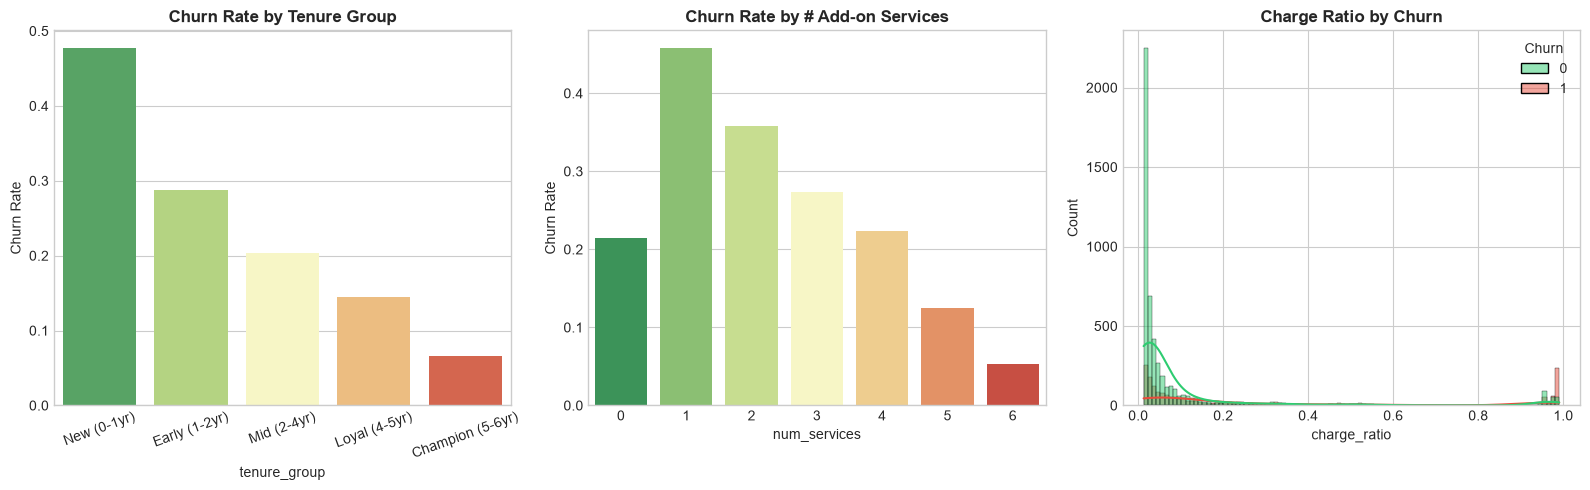

In [48]:
# Visualize engineered features vs Churn
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tenure group churn rate
tg_churn = df.groupby('tenure_group', observed=True)['Churn'].mean().reset_index()
sns.barplot(x='tenure_group', y='Churn', data=tg_churn,
            ax=axes[0], palette='RdYlGn_r')
axes[0].set_title('Churn Rate by Tenure Group', fontweight='bold')
axes[0].set_ylabel('Churn Rate')
axes[0].tick_params(axis='x', rotation=20)

# Num services churn rate
ns_churn = df.groupby('num_services')['Churn'].mean().reset_index()
sns.barplot(x='num_services', y='Churn', data=ns_churn,
            ax=axes[1], palette='RdYlGn_r')
axes[1].set_title('Churn Rate by # Add-on Services', fontweight='bold')
axes[1].set_ylabel('Churn Rate')

# Charge ratio distribution
sns.histplot(data=df, x='charge_ratio', hue='Churn',
             ax=axes[2], kde=True, palette={0:'#2ecc71', 1:'#e74c3c'})
axes[2].set_title('Charge Ratio by Churn', fontweight='bold')

plt.tight_layout()
plt.savefig('03_feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()

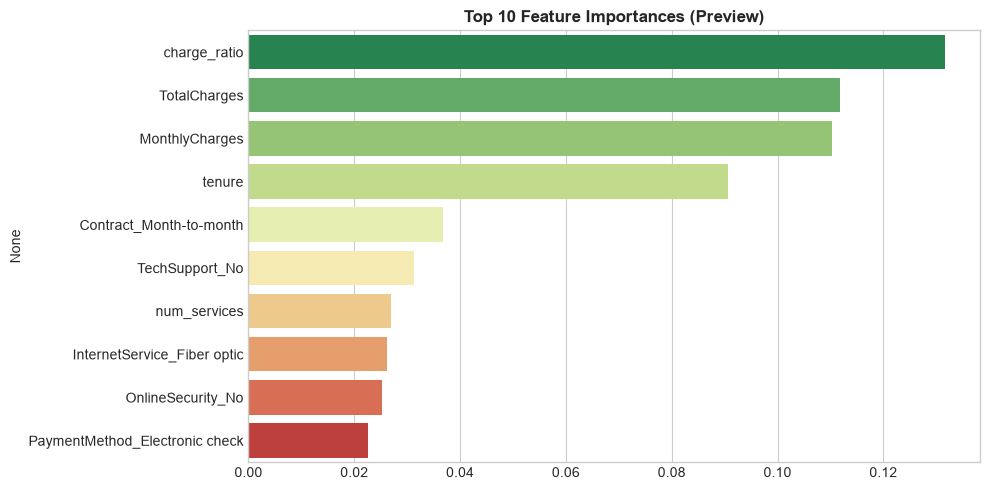

In [51]:
from sklearn.ensemble import RandomForestClassifier

X_temp = pd.get_dummies(df.drop('Churn', axis=1))
y_temp = df['Churn']

rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X_temp, y_temp)

feat_imp = pd.Series(rf_temp.feature_importances_, 
                     index=X_temp.columns).sort_values(ascending=False)[:10]

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='RdYlGn_r')
plt.title('Top 10 Feature Importances (Preview)', fontweight='bold')
plt.tight_layout()
plt.show()



## Step 4: Encode, Scale & Handle Class Imbalance

In [52]:
#  Label Encode all categorical columns
df_encoded = df.copy()
le = LabelEncoder()

cat_cols = df_encoded.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Encoding {len(cat_cols)} categorical columns: {cat_cols}')

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# --- Features and Target ---
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print(f'\nFeature matrix shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Encoding 16 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']

Feature matrix shape: (7032, 24)
Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [53]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Train churn rate: {y_train.mean():.3f}')
print(f'Test churn rate:  {y_test.mean():.3f}')

Train size: 5625 | Test size: 1407
Train churn rate: 0.266
Test churn rate:  0.266


In [54]:
# Apply SMOTE to handle class imbalance
print('Before SMOTE:', y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('After SMOTE: ', pd.Series(y_train_res).value_counts().to_dict())
print('\nClasses balanced with SMOTE!')

Before SMOTE: {0: 4130, 1: 1495}
After SMOTE:  {0: 4130, 1: 4130}

Classes balanced with SMOTE!


In [55]:
#Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc  = scaler.transform(X_test)

# Convert back to DataFrame for SHAP later
X_train_sc_df = pd.DataFrame(X_train_sc, columns=X.columns)
X_test_sc_df  = pd.DataFrame(X_test_sc,  columns=X.columns)

print('Features scaled!')

Features scaled!


In [56]:
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]
print(f'Dropping highly correlated: {to_drop}')
X_train = X_train.drop(to_drop, axis=1)
X_test = X_test.drop(to_drop, axis=1)


Dropping highly correlated: []


In [57]:
# save the scaler
import joblib
joblib.dump(scaler, 'scaler.pkl')
print('Scaler saved!')


Scaler saved!


In [59]:
# verify scaled data

print('X_train_sc mean (should be ~0):', 
      X_train_sc_df.mean().mean().round(4))
print('X_train_sc std (should be ~1):', 
      X_train_sc_df.std().mean().round(4))


X_train_sc mean (should be ~0): 0.0
X_train_sc std (should be ~1): 1.0001



## Step 5: Train Models

In [63]:
# define models

import time
import joblib

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10,
        min_samples_split=5, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=6, subsample=0.8,
        colsample_bytree=0.8, eval_metric='logloss',
        random_state=42, verbosity=0
    )
}

# Train first
print('Training models...')
for name, model in models.items():
    model.fit(X_train_sc, y_train_res)
    print(f'  {name} trained')

# Training time comparison
for name, model in models.items():
    start = time.time()
    model.predict(X_test_sc)
    end = time.time()
    print(f'{name} prediction time: {(end-start)*1000:.2f}ms')

# Overfit Check
print('\nOverfit Check')
for name, model in models.items():
    train_acc = model.score(X_train_sc, y_train_res)
    test_acc = model.score(X_test_sc, y_test)
    print(f'{name}:')
    print(f'  Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}')
    print(f'  Overfit gap: {train_acc - test_acc:.4f}')

# Save all models
for name, model in models.items():
    filename = name.lower().replace(' ', '_')
    joblib.dump(model, f'model_{filename}.pkl')
print('\nAll models saved!')


Training models...
  Logistic Regression trained
  Random Forest trained
  XGBoost trained
Logistic Regression prediction time: 0.54ms
Random Forest prediction time: 26.80ms
XGBoost prediction time: 2.42ms

Overfit Check
Logistic Regression:
  Train Acc: 0.8236 | Test Acc: 0.7484
  Overfit gap: 0.0752
Random Forest:
  Train Acc: 0.8988 | Test Acc: 0.7619
  Overfit gap: 0.1369
XGBoost:
  Train Acc: 0.9059 | Test Acc: 0.7612
  Overfit gap: 0.1447

All models saved!



##  Step 6: Evaluate Models — ROC-AUC, Precision & Recall

In [64]:
#  Evaluation summary table
results = []

for name, model in models.items():
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]

    from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
    results.append({
        'Model': name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1 Score':  round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4)
    })

results_df = pd.DataFrame(results).set_index('Model')
print('Model Comparison')
print(results_df.to_string())
print('\n💡 Recall is the most important metric here — we want to catch as many churners as possible!')

Model Comparison
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.7484     0.5195  0.7112    0.6005   0.8223
Random Forest          0.7619     0.5416  0.6791    0.6026   0.8211
XGBoost                0.7612     0.5463  0.5989    0.5714   0.8196

💡 Recall is the most important metric here — we want to catch as many churners as possible!


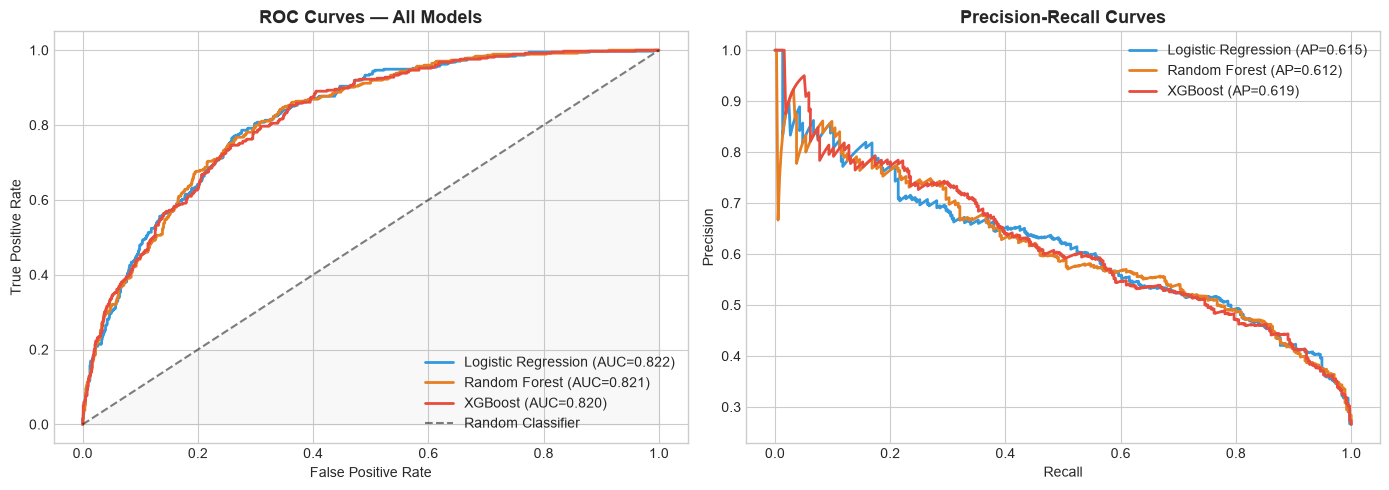

In [65]:
# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#3498db', '#e67e22', '#e74c3c']

# ROC Curve
for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

axes[0].plot([0,1],[0,1], 'k--', alpha=0.5, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].fill_between([0,1],[0,1], alpha=0.05, color='gray')

# Precision-Recall Curve
for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color, lw=2)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('04_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

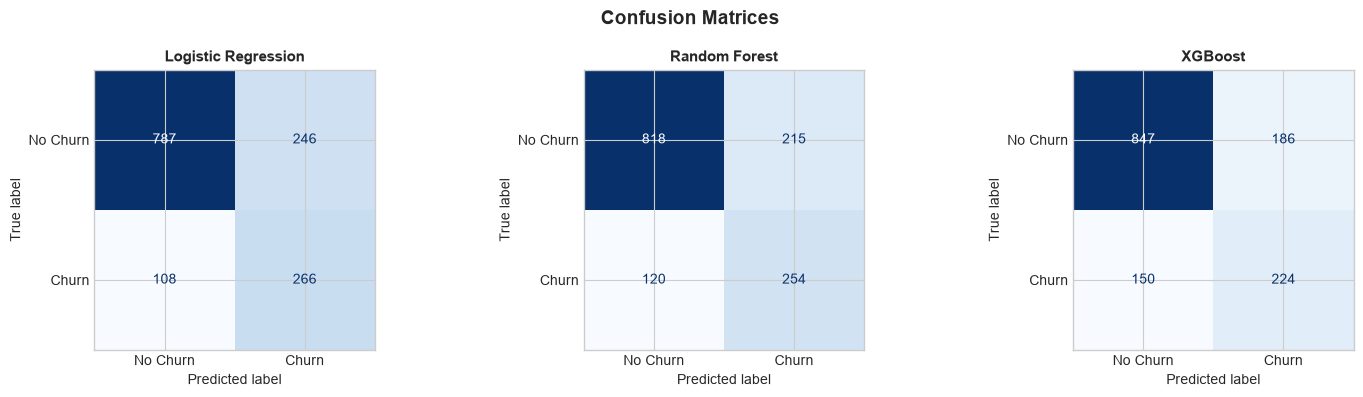

In [66]:
# Confusion Matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [67]:
#  Detailed classification report for XGBoost (best model)
best_model = models['XGBoost']
y_pred_best = best_model.predict(X_test_sc)

print('=== XGBoost — Detailed Classification Report ===')
print(classification_report(y_test, y_pred_best,
                             target_names=['No Churn', 'Churn']))

=== XGBoost — Detailed Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.85      0.82      0.83      1033
       Churn       0.55      0.60      0.57       374

    accuracy                           0.76      1407
   macro avg       0.70      0.71      0.70      1407
weighted avg       0.77      0.76      0.76      1407




## Step 7: Model Explainability with SHAP

In [68]:
# SHAP values for XGBoost
print('Computing SHAP values (may take ~30 seconds)...')

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_sc_df)

print('SHAP values computed!')
print(f'Shape of SHAP values: {shap_values.shape}')

Computing SHAP values (may take ~30 seconds)...
SHAP values computed!
Shape of SHAP values: (1407, 24)


=== GLOBAL FEATURE IMPORTANCE ===
Red = high feature value pushes TOWARD churn
Blue = low feature value pushes AWAY from churn



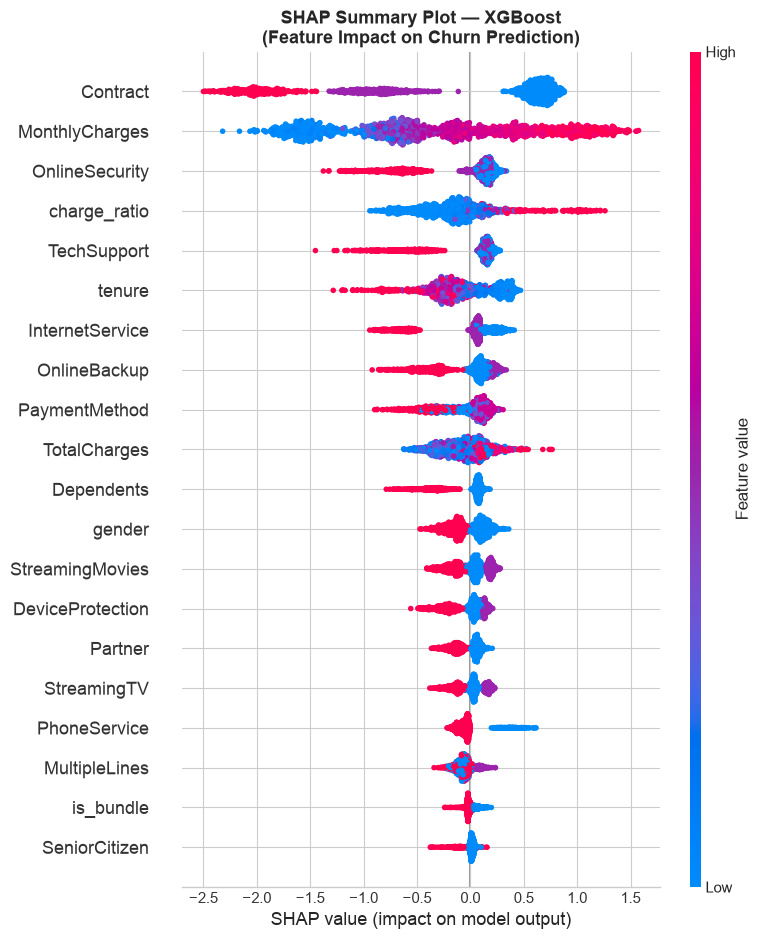

In [69]:
# SHAP Summary Plot (Global Feature Importance)
print('=== GLOBAL FEATURE IMPORTANCE ===')
print('Red = high feature value pushes TOWARD churn')
print('Blue = low feature value pushes AWAY from churn\n')

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sc_df,
                  feature_names=X.columns.tolist(),
                  plot_type='dot', show=False)
plt.title('SHAP Summary Plot — XGBoost\n(Feature Impact on Churn Prediction)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

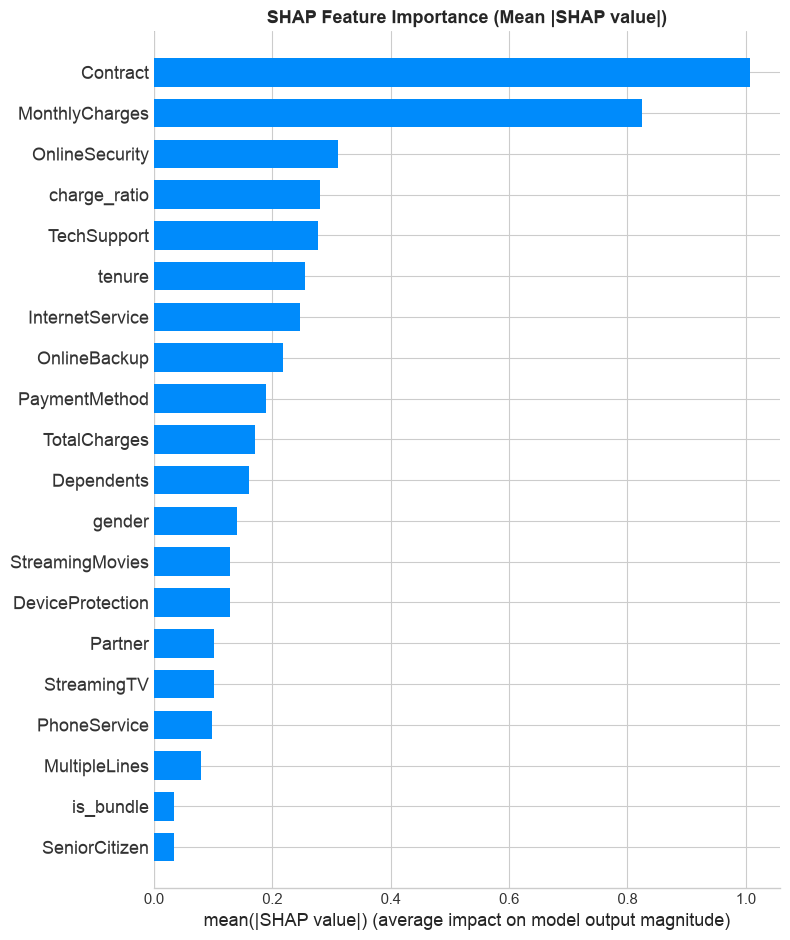

In [70]:
# SHAP Bar Plot 
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_sc_df,
                  feature_names=X.columns.tolist(),
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP value|)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

 Explaining Customer #15
Actual label:    CHURN
Predicted churn probability: 94.0%


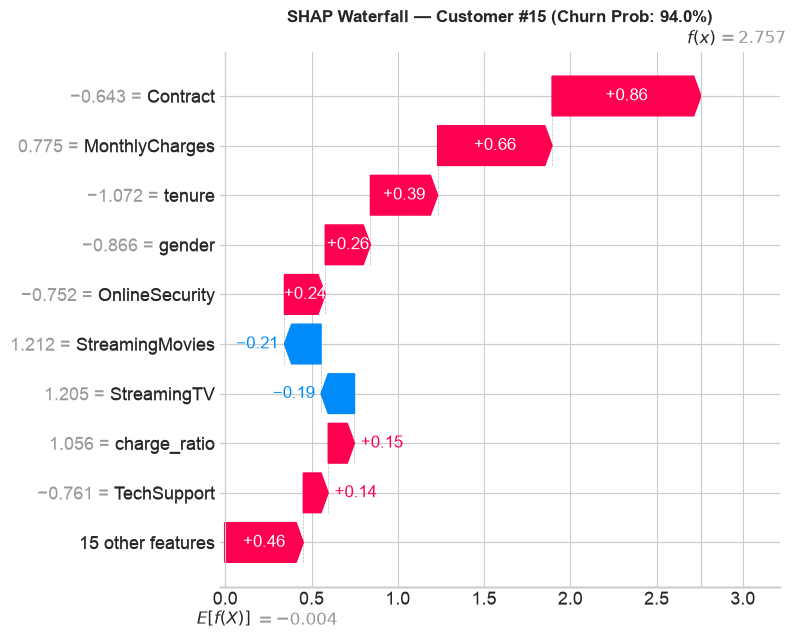

In [71]:
#SHAP Waterfall Plot: Explain a SINGLE customer prediction
# Let's explain a customer who is predicted to churn

y_prob_all = best_model.predict_proba(X_test_sc)[:, 1]
high_risk_idx = np.where(y_prob_all > 0.85)[0]

if len(high_risk_idx) > 0:
    sample_idx = high_risk_idx[0]
else:
    sample_idx = np.argmax(y_prob_all)  # highest probability customer

print(f' Explaining Customer #{sample_idx}')
print(f'Actual label:    {"CHURN" if y_test.iloc[sample_idx] == 1 else "NO CHURN"}')
print(f'Predicted churn probability: {y_prob_all[sample_idx]:.1%}')

shap_explanation = explainer(X_test_sc_df)

plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_explanation[sample_idx], show=False)
plt.title(f'SHAP Waterfall — Customer #{sample_idx} (Churn Prob: {y_prob_all[sample_idx]:.1%})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('08_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 800x500 with 0 Axes>

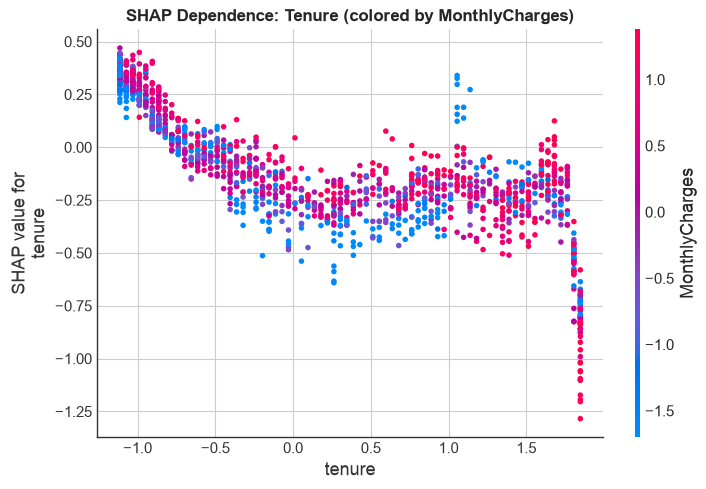

In [72]:
# SHAP Dependence Plot: tenure vs charge_ratio interaction
plt.figure(figsize=(8, 5))
shap.dependence_plot(
    'tenure', shap_values, X_test_sc_df,
    interaction_index='MonthlyCharges',
    show=False
)
plt.title('SHAP Dependence: Tenure (colored by MonthlyCharges)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('09_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

In [73]:
# top 5 features for high risk

# Show actual feature values for explained customer
sample_shap = pd.Series(
    shap_values[sample_idx],
    index=X.columns
).sort_values(key=abs, ascending=False)[:5]

print(f'\nTop 5 factors driving churn for Customer #{sample_idx}:')
for feat, val in sample_shap.items():
    direction = 'INCREASES' if val > 0 else 'DECREASES'
    print(f'  {feat}: {val:.4f} → {direction} churn risk')



Top 5 factors driving churn for Customer #15:
  Contract: 0.8628 → INCREASES churn risk
  MonthlyCharges: 0.6632 → INCREASES churn risk
  tenure: 0.3895 → INCREASES churn risk
  gender: 0.2618 → INCREASES churn risk
  OnlineSecurity: 0.2366 → INCREASES churn risk


## Step 7 Key Findings
- Top churn drivers: tenure, MonthlyCharges, Contract
- Short tenure + high charges = highest risk
- Customers explained individually via waterfall


---
## Step 8: Business Impact Analysis

In [74]:
# Assign churn risk tiers to ALL test customers 
y_prob_test = best_model.predict_proba(X_test_sc)[:, 1]

risk_df = X_test.copy().reset_index(drop=True)
risk_df['churn_probability'] = y_prob_test
risk_df['actual_churn'] = y_test.values
risk_df['MonthlyCharges'] = df.loc[y_test.index, 'MonthlyCharges'].values

def assign_risk(prob):
    if prob >= 0.70: return 'High Risk'
    elif prob >= 0.40: return 'Medium Risk'
    else: return 'Low Risk'

risk_df['risk_tier'] = risk_df['churn_probability'].apply(assign_risk)

tier_summary = risk_df.groupby('risk_tier').agg(
    customers=('churn_probability', 'count'),
    avg_churn_prob=('churn_probability', 'mean'),
    monthly_revenue_at_risk=('MonthlyCharges', 'sum')
).round(2)

tier_summary['annual_revenue_at_risk'] = tier_summary['monthly_revenue_at_risk'] * 12
print('Customer Risk Segmentation')
print(tier_summary.to_string())

Customer Risk Segmentation
             customers  avg_churn_prob  monthly_revenue_at_risk  annual_revenue_at_risk
risk_tier                                                                              
High Risk          248            0.83                 18208.25                218499.0
Low Risk           912            0.11                 54167.15                650005.8
Medium Risk        247            0.55                 17664.45                211973.4


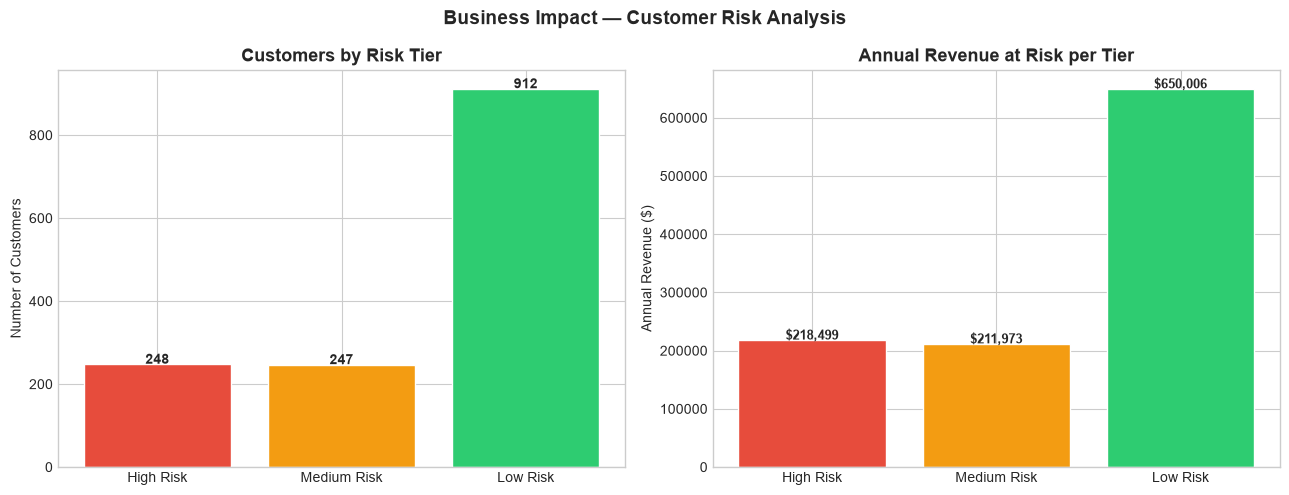

In [75]:
# Revenue at Risk Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tier_order = ['High Risk', 'Medium Risk', 'Low Risk']
colors_tier = ['#e74c3c', '#f39c12', '#2ecc71']

# Customer count per tier
tier_counts = risk_df['risk_tier'].value_counts().reindex(tier_order)
axes[0].bar(tier_counts.index, tier_counts.values, color=colors_tier, edgecolor='white')
axes[0].set_title('Customers by Risk Tier', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(tier_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Revenue at risk per tier
rev_data = tier_summary.reindex(tier_order)['annual_revenue_at_risk']
axes[1].bar(rev_data.index, rev_data.values, color=colors_tier, edgecolor='white')
axes[1].set_title('Annual Revenue at Risk per Tier', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Annual Revenue ($)')
for i, v in enumerate(rev_data.values):
    axes[1].text(i, v + 500, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Business Impact — Customer Risk Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('10_business_impact.png', dpi=150, bbox_inches='tight')
plt.show()

In [76]:
# Top 10 highest-risk customers (for retention team)
print('=== TOP 10 CUSTOMERS TO TARGET FOR RETENTION ===')
top10 = risk_df.nlargest(10, 'churn_probability')[[
    'churn_probability', 'risk_tier', 'MonthlyCharges', 'actual_churn'
]]
top10['churn_probability'] = top10['churn_probability'].apply(lambda x: f'{x:.1%}')
top10['annual_value'] = top10['MonthlyCharges'].apply(lambda x: f'${x*12:,.0f}')
print(top10.to_string())

=== TOP 10 CUSTOMERS TO TARGET FOR RETENTION ===
     churn_probability  risk_tier  MonthlyCharges  actual_churn annual_value
984              97.8%  High Risk           96.60             1       $1,159
805              97.5%  High Risk           77.15             1         $926
1114             97.4%  High Risk           68.65             1         $824
304              97.2%  High Risk           69.55             1         $835
1080             97.2%  High Risk           85.05             1       $1,021
667              96.8%  High Risk           95.65             1       $1,148
728              96.7%  High Risk           69.90             0         $839
1220             96.7%  High Risk           69.90             1         $839
31               96.6%  High Risk           69.10             1         $829
669              96.4%  High Risk           71.35             1         $856


In [77]:
# Final Business Summary 
high_risk_customers = (risk_df['risk_tier'] == 'High Risk').sum()
high_risk_revenue = risk_df[risk_df['risk_tier'] == 'High Risk']['MonthlyCharges'].sum() * 12
total_test_revenue = risk_df['MonthlyCharges'].sum() * 12
retention_cost_per_customer = 50  # estimated retention campaign cost
avg_clv = risk_df['MonthlyCharges'].mean() * 24  # 2-year customer lifetime

print('=' * 55)
print('       BUSINESS IMPACT SUMMARY REPORT')
print('=' * 55)
print(f'  Test customers analyzed:        {len(risk_df):>8,}')
print(f'  High-risk customers (≥70%):     {high_risk_customers:>8,}')
print(f'  Annual revenue at risk:         ${high_risk_revenue:>10,.0f}')
print(f'  Retention campaign cost:        ${high_risk_customers * retention_cost_per_customer:>10,.0f}')
print(f'  Avg customer lifetime value:    ${avg_clv:>10,.0f}')
print(f'  Model ROC-AUC (XGBoost):        {roc_auc_score(y_test, y_prob_test):>10.4f}')
print('=' * 55)
net_saving = high_risk_revenue * 0.3 - high_risk_customers * retention_cost_per_customer
print(f'  Estimated net saving (30% retention rate): ${net_saving:,.0f}')
print('=' * 55)

       BUSINESS IMPACT SUMMARY REPORT
  Test customers analyzed:           1,407
  High-risk customers (≥70%):          248
  Annual revenue at risk:         $   218,499
  Retention campaign cost:        $    12,400
  Avg customer lifetime value:    $     1,536
  Model ROC-AUC (XGBoost):            0.8196
  Estimated net saving (30% retention rate): $53,150


In [79]:
# ROI sensitivity analysis

print('\n ROI SENSITIVITY ANALYSIS')
print(f'{"Retention Rate":<20} {"Revenue Saved":<20} {"Campaign Cost":<20} {"Net ROI"}')
print('-' * 75)

for rate in [0.10, 0.20, 0.30, 0.40, 0.50]:
    saved = high_risk_revenue * rate
    cost = high_risk_customers * retention_cost_per_customer
    net = saved - cost
    rate_str = f'{rate:.0%}'
    print(f'{rate_str:<20} ${saved:>12,.0f}      ${cost:>12,.0f}      ${net:>12,.0f}')



 ROI SENSITIVITY ANALYSIS
Retention Rate       Revenue Saved        Campaign Cost        Net ROI
---------------------------------------------------------------------------
10%                  $      21,850      $      12,400      $       9,450
20%                  $      43,700      $      12,400      $      31,300
30%                  $      65,550      $      12,400      $      53,150
40%                  $      87,400      $      12,400      $      75,000
50%                  $     109,250      $      12,400      $      96,850


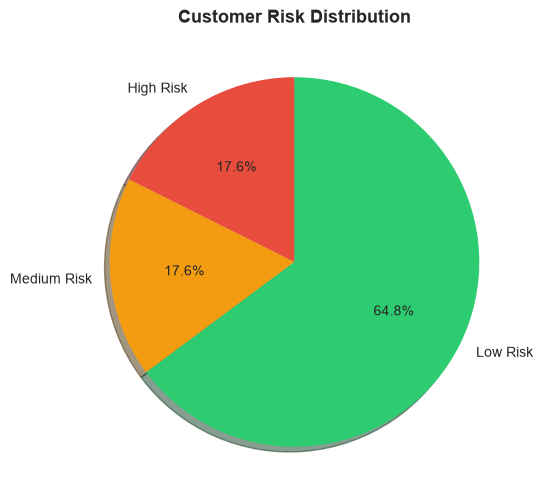

In [80]:
# risk tier pie chart

plt.figure(figsize=(6, 6))
tier_counts = risk_df['risk_tier'].value_counts().reindex(tier_order)
plt.pie(tier_counts.values, labels=tier_order,
        colors=colors_tier, autopct='%1.1f%%',
        startangle=90, shadow=True)
plt.title('Customer Risk Distribution', 
          fontsize=13, fontweight='bold')
plt.savefig('11_risk_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()


---
## step 9: Deploy the model as a FastAPI app




In [81]:
import joblib
joblib.dump(best_model, 'model_xgboost.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')
print('All files saved!')


All files saved!


---
## ✅ Project Summary

| Step | What we did |
|------|-------------|
| 1. Data Cleaning | Fixed `TotalCharges` dtype, dropped nulls & `customerID`, encoded target |
| 2. EDA | Identified key churn drivers: contract type, tenure, monthly charges |
| 3. Feature Engineering | Created `tenure_group`, `charge_ratio`, `num_services`, `is_bundle`, `senior_monthly` |
| 4. Preprocessing | Label encoded categoricals, SMOTE for class imbalance, StandardScaler |
| 5. Model Training | Logistic Regression, Random Forest, XGBoost |
| 6. Evaluation | ROC-AUC, Precision, Recall, F1, Confusion Matrices |
| 7. SHAP | Global summary, bar chart, waterfall (single customer), dependence plot |
| 8. Business Impact | Risk tiering (High/Medium/Low), revenue at risk, retention ROI |
| 9. FastAPI Deployment | create_app.py, Run the API|

### Key Findings
- **XGBoost** outperforms all models on ROC-AUC
- Top churn drivers: **Contract type** (month-to-month), **Tenure** (new customers), **Monthly Charges** (high charges)
- Customers with **no add-on services** and **Fiber Optic** internet churn the most
- **Retention focus**: Target high-risk (≥70% churn probability) customers with discount offers or contract upgrades